In [1]:
%load_ext autoreload

In [2]:
%autoreload 2

In [67]:
from functools import partial

import jax
import jax.numpy as jnp
from lsstypes import mean, cov, read
import matplotlib.pyplot as plt
from jaxpower import BinMesh2SpectrumPoles, FKPField, ParticleField, compute_fkp2_normalization, get_mesh_attrs
from tqdm import tqdm

from desiforwardwindow.convenience import fiducial_planck_2018, get_randoms
from desiforwardwindow.forward import get_AIC_foward_model, get_RIC_forward_model, mock_survey, mock_survey_diff
from desiforwardwindow.window import get_window_geometry, get_window_spikes

Example of computing the Y3 window, with RIC and AIC for LRG SGC.

# Parameter choices

In [4]:
LOS = "local"
UNITARY_AMPLITUDE = True
BATCH_SIZE = 1

regression_maps = ['STARDENS','PSFSIZE_G','PSFSIZE_R','PSFSIZE_Z','GALDEPTH_G','GALDEPTH_R','GALDEPTH_Z','EBV_DIFF_GR','EBV_DIFF_RZ','HI'] # will need to create some of those, not stored

n_bins_AIC = 10 # template bins for the regression
n_bins_RIC = 1000 # distance bins for the shells in RIC

# Data preparation

## Read randoms from disk

In [5]:
tracer = "LRG"
positions, stored_weights = get_randoms(n_randoms=3, region="SGC", zrange=(0.4, 1.1), tracer=tracer, weight_type="default")
mattrs = get_mesh_attrs(positions, cellsize=50.0, boxsize=8000.0, check=True)  # [8000.0, 16000.0, 8000.0], check=True)
data_size = 1677566 # amount of data in the corresponding data catalog

stored_weights = stored_weights[0]

## Get systematics information

In [6]:
import fitsio
import healpy as hp
import LSS.common_tools as common
from numpy.lib.recfunctions import append_fields, structured_to_unstructured

debv = common.get_debv()

sys_tab = fitsio.read(f"/dvs_ro/cfs/cdirs/desi/survey/catalogs/Y3/LSS/loa-v1/LSScats/v2/hpmaps/{tracer}_mapprops_healpix_nested_nside256_S.fits")

for col in regression_maps:
    if "DEPTH" in col:
        bnd = col.split("_")[-1]
        sys_tab[col] *= 10 ** (-0.4 * common.ext_coeff[bnd] * sys_tab["EBV"])
sys_tab = append_fields(sys_tab, names=["EBV_DIFF_" + ec for ec in ["GR", "RZ"]], data=[debv["EBV_DIFF_" + ec] for ec in ["GR", "RZ"]], usemask=False)

hpx_rand = hp.vec2pix(nside=256, x=positions[:, 0], y=positions[:, 1], z=positions[:, 2], nest=True)
template_values = structured_to_unstructured(sys_tab[regression_maps][hpx_rand]).astype(float)

del sys_tab, hpx_rand, debv

## Designate "data" and randoms

In [7]:
seed = jax.random.key(42)
data_indices_in_randoms = jax.random.choice(key=seed, a=stored_weights.size, shape=[data_size], replace=False).astype(int)
mask_is_data = jnp.zeros_like(stored_weights, dtype=bool).at[data_indices_in_randoms].set(True)
mask_is_randoms = jnp.invert(mask_is_data)

In [8]:
# Can pre-paint the randoms, since they won't move. Can't paint data.
randoms = ParticleField(positions[~mask_is_data], weights=stored_weights[~mask_is_data], attrs=mattrs, exchange=True)
randoms_mesh = randoms.paint(resampler="tsc", interlacing=3, compensate=True)
randoms_shotnoise = (randoms.weights**2).sum()
data = ParticleField(positions[mask_is_data], weights=stored_weights[mask_is_data], attrs=mattrs, exchange=True)

del positions, stored_weights

## Details for P(k) computation

In [68]:
# To go from the mesh to the observed power spectrum
# Can always rebin ell = 2 to 0.002 later
binner = BinMesh2SpectrumPoles(randoms.attrs, edges={"step": 0.001}, ells=(0, 2, 4))

# Precompute the FKP power spectrum norm, without accounting for future data painting
FKP_field = FKPField(data=data, randoms=randoms)
fkp_norm = compute_fkp2_normalization(FKP_field, bin=binner)
del FKP_field

# Fiducial theory

In [10]:
theory = fiducial_planck_2018(jnp.arange(0.0, mattrs.knyq.max(), 0.001)) # Stop at the selection's k_nyq

/global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/20250526-1.0.0/code/cosmoprimo/main/lib/python3.10/site-packages/cosmoprimo/eisenstein_hu.py:25: UserWarning: EisensteinHuEngine cannot cope with massive neutrinos
  warnings.warn('{} cannot cope with massive neutrinos'.format(self.__class__.__name__))


# Window computation

## Setup forward modeling

Start by pre-computing everything that can be, and defining some jitted, differentiable functions that simply take in the data weights and return forward modeling ones.

`get_AIC_foward_model` can be quite long due to some hefty operations on the randoms.

In [11]:
get_RIC_weights = get_RIC_forward_model(data=data, randoms=randoms, n_bins_RIC=n_bins_RIC)
get_AIC_weights = get_AIC_foward_model(data=data, randoms=randoms, template_values=template_values, mask_is_data=mask_is_data, n_bins=n_bins_AIC)

In [73]:
forward_model_pk = jax.jit(
    partial(
        mock_survey,
        theory=theory,
        los=LOS,
        unitary_amplitude=UNITARY_AMPLITUDE,
        binner=binner,
        randoms_shotnoise=randoms_shotnoise,
        fkp_norm=fkp_norm,
    ),
    static_argnames=["get_RIC_weights", "get_AIC_weights"],
)
# left: seed, data, randoms_mesh, get_AIC_weights, get_RIC_weights

In [74]:
pks_geo = [forward_model_pk(seed=jax.random.key(seed), data=data, randoms_mesh=randoms_mesh, get_RIC_weights=None, get_AIC_weights=None) for seed in tqdm(range(100))]
pks_ARIC = [forward_model_pk(seed=jax.random.key(seed), data=data, randoms_mesh=randoms_mesh, get_RIC_weights=get_RIC_weights, get_AIC_weights=get_AIC_weights) for seed in tqdm(range(100))]

100%|██████████| 100/100 [00:14<00:00,  7.11it/s]


In [75]:
pks_geo_mean = mean(pks_geo)
pks_geo_cov = cov(pks_geo)
pks_ARIC_mean = mean(pks_ARIC)
pks_ARIC_cov = cov(pks_ARIC)

## Geometry analytical estimation

In [12]:
#window_geo = get_window_geometry(selection=randoms_mesh, theory_edges=theory, theory_ells=theory.ells, binner=binner, flags=('infinite'), los=LOS, pbar=True)
window_geo = read("window_geo.h5") # otherwise about 14 minutes

100%|█████████▉| 62/62 [13:55<00:00, 13.48s/it]  


In [14]:
# window_geo.write("window_geo.h5")

## Control variate on IC

In [77]:
window_cv, windows_cv = get_window_spikes(
    mock_survey=mock_survey_diff, 
    theory=theory, 
    nreal=2, 
    seeds=None, 
    batch_size=1, 
    mock_survey_kw={
        "data":data,
        "binner":binner,
        "los":LOS,
        "unitary_amplitude":UNITARY_AMPLITUDE,
        "randoms_shotnoise":randoms_shotnoise,
        "randoms_mesh":randoms_mesh,
        "fkp_norm":fkp_norm,
        "get_RIC_weights":get_RIC_weights,
        "get_AIC_weights":get_AIC_weights,
    },
    unhashable=["data", "binner", "randoms_shotnoise", "randoms_mesh", "fkp_norm"],
)

['mock_survey', 'get_RIC_weights', 'los', 'unitary_amplitude', 'get_AIC_weights']


100%|██████████| 186/186 [01:09<00:00,  2.69it/s]


In [78]:
window = window_cv.clone(value=(window_cv.value() + window_geo.value()))

In [79]:
windowed_theory = window.dot(theory, return_type=None, zpt=False)

/global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/20250526-1.0.0/conda/lib/python3.10/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/20250526-1.0.0/conda/lib/python3.10/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Text(0.02, 0.5, '$k(W(k, q)P_\\ell(q) - P_\\ell^\\mathrm{obs}(k))$')

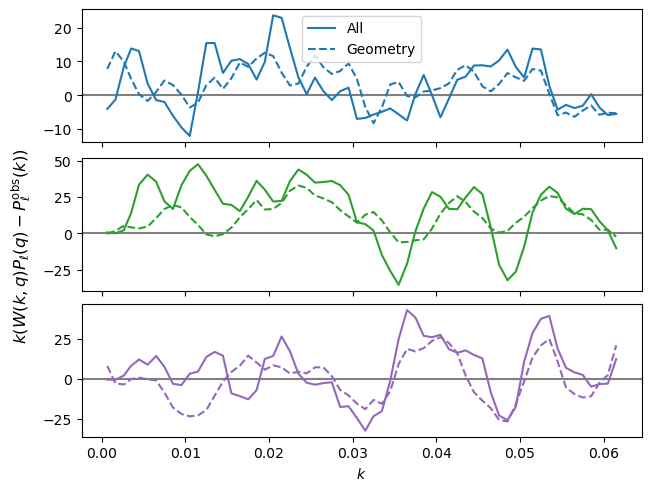

In [80]:
fig, lax = plt.subplots(3, 1, layout="constrained", sharex=True)

for ell in [0, 2, 4]:
    lax[ell//2].axhline(0, color="gray")
    color = f"C{ell}"
    pole_theo_all = windowed_theory.get(ell)
    pole_theo_geo = window_geo.dot(theory, return_type=None, zpt=False).get(ell)

    pole_all = pks_ARIC_mean.get(ell)
    pole_geo = pks_geo_mean.get(ell)
    
    lax[ell//2].plot(pole_theo_all.coords('k'), pole_theo_all.coords('k') * (pole_theo_all.value() - pole_all.value()), color=color, ls='-', label="All")
    lax[ell//2].plot(pole_theo_geo.coords('k'), pole_theo_geo.coords('k') * (pole_theo_geo.value() - pole_geo.value()), color=color, ls='--', label="Geometry")

lax[0].legend()
plt.xlabel("$k$")
fig.supylabel(r"$k(W(k, q)P_\ell(q) - P_\ell^\mathrm{obs}(k))$")
    